# CEM run from a CoastSat shoreline (parameter-driven)

Set a site + year in the **Parameters** cell, then *Run All*. The notebook calls
`coastsat_single_site.py` to build the shoreline, figures out which side is land
on its own, grids it, runs coupled CEM+Waves, and plots the result.

- To model a different beach: change `SITE` (and maybe `YEAR`) and re-run.
- To use a shoreline file you already have: set `XY_PATH` (and `LAND_DIR`).
- The only paths you edit once are in the Parameters cell.


## 0. Parameters — normally the only cell you edit

In [1]:
# ============================ PARAMETERS ============================
import os
# ---- INPUT MODE -------------------------------------------------------------
# Either (A) generate a shoreline from the dataset by SITE+YEAR, or
#        (B) load a ready-made .xy file. XY_PATH picks which:
#          XY_PATH = ""                    -> mode A (SITE/YEAR, land_dir auto)
#          XY_PATH = "Erie_spit_ESPIn.xy"  -> mode B (load file, set LAND_DIR by hand)
XY_PATH = ""     # <- "" to use SITE/YEAR instead

# ---- mode A: dataset shoreline (ignored when XY_PATH is set) ----
SITE = "usa_NC_0030"               # any usa_XX_00nn folder under the data dir
YEAR = 2020                        # ~1984..2025
# paths: leave None to AUTO-DISCOVER (or set env CEM_EXTRACTOR_DIR / CEM_DATA_DIR / CEM_TRANSECTS)
EXTRACTOR_DIR = os.environ.get("CEM_EXTRACTOR_DIR")
DATA_DIR      = os.environ.get("CEM_DATA_DIR")
TRANSECTS     = os.environ.get("CEM_TRANSECTS")

# ---- land direction ----
# mode A: leave None to auto-derive from transect orientation.
# mode B: REQUIRED (a raw .xy has no orientation). (0,-1) works with ALIGN_COAST;
#         flip to (0,1) if land/ocean come out reversed (the grid cell warns).
LAND_DIR = (0, -1)                 # None (mode A auto)  or  (0,-1) / (-1,1)

# ---- grid ----
DX = DY     = 100                  # metres per cell
ALIGN_COAST = True                 # rotate coast ~horizontal (recommended; stabler for CEM)
CROSS_PAD   = 30                   # cross-shore room in cells

# ---- waves ----
WAVE_HEIGHT = 1.5
WAVE_PERIOD = 7.0
ASYMMETRY   = 0.5                  # Ashton approach-angle asymmetry
HIGHNESS    = 0.5                  # Ashton approach-angle highness

# ---- run ----
N_STEPS    = 200                   # if the kernel ever dies mid-run, lower this (40, 20, 10)
SAVE_EVERY = 4                     # capture a frame every N steps
SED_RATE   = 500.0                 # sediment source strength at one cell (0 = none)
# ===================================================================
_mode = f"file: {XY_PATH}" if XY_PATH else f"{SITE} {YEAR}"
print(f"parameters set | input = {_mode} | LAND_DIR = {LAND_DIR} | N_STEPS = {N_STEPS}")

parameters set | input = usa_NC_0030 2020 | LAND_DIR = (0, -1) | N_STEPS = 200


## 1. Locate inputs + imports

Paths auto-discover here; nothing to edit if your data is under `./data/shoreline_data/` and `coastsat_single_site.py` is in the repo.

In [2]:
import os, sys, time, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import path
from scipy.spatial import cKDTree
%matplotlib inline

def _find_extractor_dir():
    p = Path(os.getcwd()).resolve(); bases = [p]
    for _ in range(5):
        if p.parent == p: break
        p = p.parent; bases.append(p)
    for base in bases:
        if (base / "coastsat_single_site.py").is_file():
            return str(base)
    for base in bases:
        hits = sorted(glob.glob(str(base / "*" / "coastsat_single_site.py")))
        if hits:
            return str(Path(hits[0]).parent)
    return None

css = None
if XY_PATH:
    # Using an existing .xy: no dataset, no extractor needed.
    print("XY_PATH is set -> loading an existing .xy; skipping dataset discovery.")
else:
    EXTRACTOR_DIR = EXTRACTOR_DIR or _find_extractor_dir()
    if not EXTRACTOR_DIR:
        raise FileNotFoundError("coastsat_single_site.py not found near this notebook. "
            "Put it beside the notebook or at the repo root, or set CEM_EXTRACTOR_DIR.")
    if EXTRACTOR_DIR not in sys.path:
        sys.path.insert(0, EXTRACTOR_DIR)
    import coastsat_single_site as css
    DATA_DIR  = DATA_DIR  or css.find_site_data()
    TRANSECTS = TRANSECTS or css.find_transects_file()
    if not DATA_DIR:
        raise FileNotFoundError("Could not find the usa_* site folders. Unzip "
            "shoreline_data.zip under ./data/shoreline_data/ (or set CEM_DATA_DIR).")
    if not TRANSECTS:
        raise FileNotFoundError("Could not find a transects geojson. Place "
            "US_East_transects.geojson under ./data/shoreline_data/ (or set CEM_TRANSECTS).")
    print("EXTRACTOR_DIR:", EXTRACTOR_DIR)
    print("DATA_DIR     :", DATA_DIR)
    print("TRANSECTS    :", TRANSECTS)

EXTRACTOR_DIR: /home/jupyter-waveletswave/cem_xy
DATA_DIR     : /home/jupyter-waveletswave/cem_xy/csv_run7
TRANSECTS    : /home/jupyter-waveletswave/cem_xy/US_East_transects.geojson


### Helper: open-coast grid builder

In [3]:
def align_shoreline(x, y, land_dir):
    """Rotate the coast to ~horizontal AND orient so LAND ends at LOW cross-shore
    rows (row 0). CEM's built-in convention is land at row 0 / ocean at high rows
    (its river source is qs[0, col]); getting this backwards makes CEM's seaward
    scan run off the grid -> the `ERROR: x>=...` crash. Returns (xr, yr, (0,-1), angle_deg)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    cx, cy = x.mean(), y.mean()
    X = np.column_stack([x - cx, y - cy])
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    th = np.arctan2(vt[0, 1], vt[0, 0])
    c, s = np.cos(-th), np.sin(-th)
    XY = (np.array([[c, -s], [s, c]]) @ X.T).T
    xr, yr = XY[:, 0] + cx, XY[:, 1] + cy
    ld = np.array([[c, -s], [s, c]]) @ np.asarray(land_dir, float)
    if ld[1] >= 0:                       # land would be up -> reflect so it is at LOW y
        yr = 2 * yr.mean() - yr
    return xr, yr, (0.0, -1.0), float(np.degrees(th))


def close_to_land_polygon(x, y, land_dir):
    """Extend the open shoreline far landward (and past both ends) so its interior
    is the whole LAND side -- covering the cross-shore grid edges too."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    ux, uy = np.asarray(land_dir, float); nrm = np.hypot(ux, uy); ux, uy = ux/nrm, uy/nrm
    reach = 3.0 * np.hypot(np.ptp(x), np.ptp(y))
    xs = np.concatenate([[x[0]-reach], x, [x[-1]+reach, x[-1]+ux*reach, x[0]-reach+ux*reach]])
    ys = np.concatenate([[y[0]],       y, [y[-1],       y[-1]+uy*reach, y[0]+uy*reach]])
    return np.column_stack([xs, ys])


def shorelinetogrid_open(x, y, dx, dy, land_dir, pad_x=0, pad_y=30):
    """xy shoreline -> Dean-profile depth grid for OPEN coastlines, oriented for
    CEM (land at low rows, ocean at high rows). pad_y = cross-shore room (cells);
    pad_x = 0 keeps the coast spanning the full width (no all-ocean gap columns,
    which CEM's periodic alongshore needs). Returns (xg, yg, zg); domain = -zg.T."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    A = 0.1; rng = 100000
    x0 = int(np.floor(min(x)/dx)*dx) - pad_x*dx
    y0 = int(np.floor(min(y)/dy)*dy) - pad_y*dy
    x1 = int(np.ceil(max(x)/dx)*dx)  + pad_x*dx
    y1 = int(np.ceil(max(y)/dy)*dy)  + pad_y*dy
    xg, yg = np.meshgrid(np.arange(x0, x1, dx), np.arange(y0, y1, dy),
                         sparse=False, indexing="ij")
    tree = cKDTree(np.column_stack([x, y]))
    nn, _ = tree.query(np.column_stack([xg.ravel(), yg.ravel()]),
                       k=1, distance_upper_bound=rng)
    nn[np.isinf(nn)] = np.sqrt(1.e10)
    dist = nn.reshape(xg.shape)
    zg = -A * dist**(2/3)
    IN = path.Path(close_to_land_polygon(x, y, land_dir)).contains_points(
        np.transpose([xg.flatten(), yg.flatten()])).reshape(xg.shape)
    zg[IN] = (np.min(A * (dist[IN])**(2/3))) + 1
    return xg, yg, zg * -1

print("helpers ready")

helpers ready


## 2. Get the shoreline

Either generate it from the CoastSat dataset for `SITE`/`YEAR` (default), or load
an existing `.xy` if `XY_PATH` is set. When generating, the land direction is
detected automatically from the transect orientation.

usa_NC_0030 2020: 172 points, EPSG:32618, land_dir = (0, -1)  (overridden)
aligned coast to horizontal (rotated 21.2 deg); land_dir -> (0.0, -1.0)


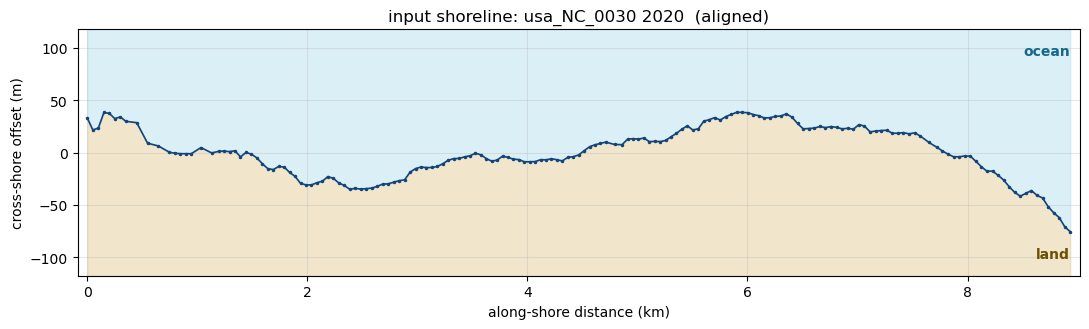

In [4]:
if XY_PATH:
    data = np.loadtxt(XY_PATH)
    x, y = data[:, 0], data[:, 1]
    UTM_EPSG = None
    if LAND_DIR is None:
        raise ValueError("A raw .xy carries no transect orientation -- set LAND_DIR "
                         "in the Parameters cell (e.g. (-1, 1) for land-to-the-NW).")
    land_dir = LAND_DIR
    label = XY_PATH
    print(f"loaded {len(x)} points from {XY_PATH}")
else:
    res = css.shoreline_for_cem(SITE, YEAR, data_dir=DATA_DIR, transects=TRANSECTS)
    x, y = np.asarray(res.x), np.asarray(res.y)
    UTM_EPSG = res.epsg
    land_dir = LAND_DIR if LAND_DIR is not None else res.land_dir
    label = f"{SITE} {YEAR}"
    print(f"{label}: {res.n} points, EPSG:{res.epsg}, "
          f"land_dir = {tuple(round(v, 2) for v in land_dir)}"
          + ("  (overridden)" if LAND_DIR is not None else "  (auto)"))

# rotate the coast to ~horizontal: cleaner for CEM and avoids the diagonal geometry
# that triggers the v0 shadow bug early.
align_angle = 0.0
if ALIGN_COAST:
    x, y, land_dir, align_angle = align_shoreline(x, y, land_dir)
    print(f"aligned coast to horizontal (rotated {align_angle:.1f} deg); land_dir -> {land_dir}")

# --- input shoreline plot ----------------------------------------------------
ld = np.asarray(land_dir, float)
closed = np.hypot(x[0]-x[-1], y[0]-y[-1]) < 0.05 * max(np.ptp(x), np.ptp(y))
thin   = (not closed) and (np.ptp(x) / max(np.ptp(y), 1.0) > 8)
if thin:
    # long, thin coast: a wide, short panel with relative axes beats forcing equal
    # aspect (which squashes a ~10 km x ~50 m strip into an unreadable sliver).
    xs = (x - x.min()) / 1000.0       # along-shore, km from origin
    ys =  y - y.mean()                # cross-shore offset, m (~0 at the coast)
    fig, ax = plt.subplots(figsize=(11, 3.4))
    ax.plot(xs, ys, "-", lw=1.2, color="#13447a", zorder=3)
    ax.plot(xs, ys, ".", ms=3,    color="#13447a", zorder=3)
    half = max(np.ptp(ys), 40) * 0.9 + 15
    ax.set_ylim(ys.mean() - half, ys.mean() + half)
    ylo, yhi = ax.get_ylim(); down = ld[1] < 0
    ax.fill_between(xs, ys, ylo if down else yhi, color="#e6d3a3", alpha=.55, zorder=0)
    ax.fill_between(xs, ys, yhi if down else ylo, color="#bfe2f0", alpha=.55, zorder=0)
    ax.text(.99, .06 if down else .94, "land",  transform=ax.transAxes, ha="right",
            va="bottom" if down else "top", color="#6b4e00", fontweight="bold")
    ax.text(.99, .94 if down else .06, "ocean", transform=ax.transAxes, ha="right",
            va="top" if down else "bottom", color="#15688c", fontweight="bold")
    ax.set_xlabel("along-shore distance (km)"); ax.set_ylabel("cross-shore offset (m)")
    ax.margins(x=0.01)
else:
    # compact or closed coast (e.g. a spit loop): equal aspect, but relative km axes
    # so ticks don't collide. A closed ring shades its interior as land.
    xs = (x - x.min()) / 1000.0; ys = (y - y.min()) / 1000.0
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(xs, ys, ".-", ms=3, color="#13447a"); ax.set_aspect("equal")
    ax.set_xlabel("Easting (km from origin)"); ax.set_ylabel("Northing (km from origin)")
    if closed:
        ax.fill(xs, ys, color="#e6d3a3", alpha=.4, zorder=0)
        ax.text(.02, .98, "closed loop  —  land = interior", transform=ax.transAxes,
                va="top", color="#6b4e00", fontweight="bold")
    else:
        cx, cy = xs.mean(), ys.mean(); span = .18 * max(np.ptp(xs), np.ptp(ys))
        u = ld / np.hypot(*ld)
        ax.annotate("", xy=(cx+u[0]*span, cy+u[1]*span), xytext=(cx, cy),
                    arrowprops=dict(arrowstyle="->", color="green", lw=2))
        ax.text(cx+u[0]*span, cy+u[1]*span, " land", color="green", fontweight="bold")
ax.grid(True, alpha=.3)
ax.set_title(f"input shoreline: {label}" + ("  (aligned)" if ALIGN_COAST else ""))
plt.tight_layout(); plt.show()

## 3. Build the initial grid (open-coast land mask)

grid (90, 62)  (5580 cells), land 51% in 0.008s


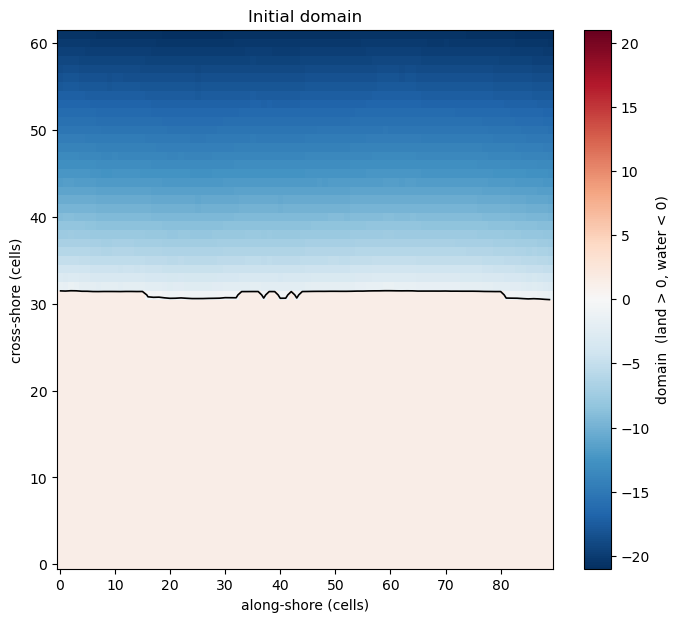

In [5]:
t0 = time.perf_counter()
PAD_Y = CROSS_PAD if ALIGN_COAST else 10      # cross-shore room (cells) when the coast is aligned
xg, yg, zg = shorelinetogrid_open(x, y, DX, DY, land_dir=land_dir, pad_x=0, pad_y=PAD_Y)
domain0 = -1.0 * zg.T
land_frac = float((domain0 > 0).mean())
print(f"grid {zg.shape}  ({zg.size} cells), land {land_frac*100:.0f}% "
      f"in {time.perf_counter()-t0:.3f}s")
if land_frac < 0.03:
    print("WARNING: almost no land -- flip LAND_DIR's sign in the Parameters cell.")

vmax = float(np.nanmax(np.abs(domain0)))
plt.figure(figsize=(8, 7))
im = plt.imshow(domain0, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
plt.colorbar(im, label="domain  (land > 0, water < 0)")
plt.contour(domain0, levels=[0], colors="k", linewidths=1.2)
plt.title("Initial domain"); plt.xlabel("along-shore (cells)"); plt.ylabel("cross-shore (cells)")
plt.show()

## 4. Initialize CEM + Waves

Domain convention: land > 0, water < 0 (so we negate and transpose `zg`).

In [6]:
from pymt.models import Cem, Waves

waves = Waves(); cem = Cem()
domain = -1.0 * zg.T.copy()           # land > 0, water < 0
n_rows, n_cols = domain.shape
print("domain shape (rows, cols):", domain.shape)

args = cem.setup(number_of_rows=n_rows, number_of_cols=n_cols, grid_spacing=float(DX))
waves.initialize(*waves.setup())
cem.initialize(*args)

waves.set_value("sea_surface_water_wave__height", WAVE_HEIGHT)
waves.set_value("sea_surface_water_wave__period", WAVE_PERIOD)
waves.set_value("sea_shoreline_wave~incoming~deepwater__ashton_et_al_approach_angle_highness_parameter", HIGHNESS)
waves.set_value("sea_shoreline_wave~incoming~deepwater__ashton_et_al_approach_angle_asymmetry_parameter", ASYMMETRY)

cem.set_value("sea_surface_water_wave__height", WAVE_HEIGHT)
cem.set_value("sea_surface_water_wave__period", WAVE_PERIOD)
cem.set_value("land_surface__elevation", domain.flatten())
print("CEM + Waves initialized")

domain shape (rows, cols): (62, 90)
CEM + Waves initialized


Setting end time to 3650
CEM: trying to open file: cem.txt
CEM: line: 62, 90, 100.0, 1

CEM: number of rows, columns: 62, 90
*** Grid size is (0,0)
*** Requested size is (62,180)
*** New grid size is (62,180)
/opt/tljh/user/envs/pymt/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


## 5. Run (sparse frame capture)

The C core is fast; only plotting is slow, so we save the state every
`SAVE_EVERY` steps. If it crashes with `xtest is uninitialized!`, that is the v0
shadow bug — lower `N_STEPS`.

In [7]:
alpha = "sea_surface_water_wave__azimuth_angle_of_opposite_of_phase_velocity"

qs = np.zeros((n_rows, n_cols))
qs[0, n_cols // 2] = SED_RATE         # sediment source at one cell (0 array = none)

frames = []
t0 = time.perf_counter()
for t in range(N_STEPS):
    waves.update()
    cem.set_value(alpha, waves.get_value(alpha))
    cem.set_value("land_surface_water_sediment~bedload__mass_flow_rate", qs)
    cem.update()
    if t % SAVE_EVERY == 0 or t == N_STEPS - 1:
        z = cem.get_value("sea_water__depth").reshape(domain.shape).copy()
        frames.append((t, z))

print(f"ran {N_STEPS} steps in {time.perf_counter()-t0:.2f}s, captured {len(frames)} frames")

ran 200 steps in 0.15s, captured 51 frames


## 6. Before / after

In [8]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def pick_frames(target_steps):
    out = []
    for s in target_steps:
        idx = min(range(len(frames)), key=lambda i: abs(frames[i][0] - s))
        out.append(frames[idx])
    return out

last = frames[-1][0]
KEY_STEPS = [0, last // 2, last]
print("frames available:", [f[0] for f in frames])

frames available: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152, 156, 160, 164, 168, 172, 176, 180, 184, 188, 192, 196, 199]


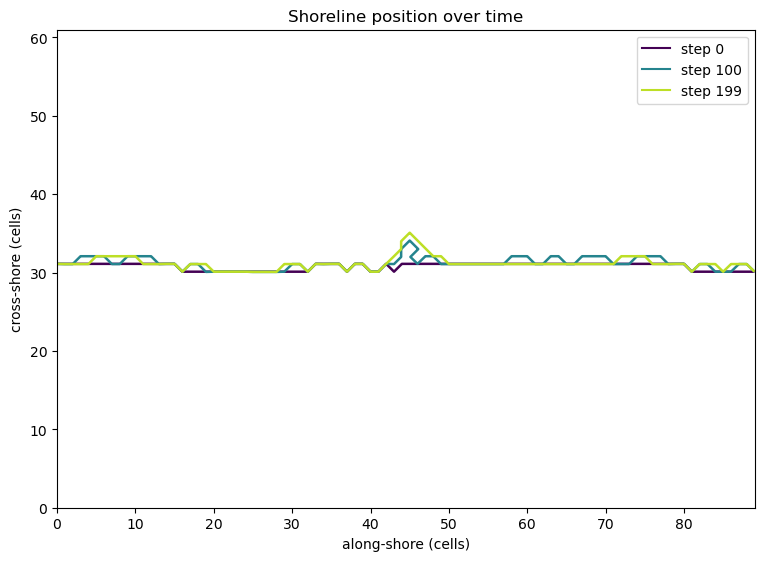

In [9]:
# 1) Shoreline position over time
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(KEY_STEPS)))
handles = []
for c, (step, z) in zip(colors, pick_frames(KEY_STEPS)):
    ax.contour(z, levels=[0], colors=[c], linewidths=1.8)
    handles.append(Line2D([0], [0], color=c, label=f"step {step}"))
ax.set_aspect("equal")
ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
ax.set_title("Shoreline position over time"); ax.legend(handles=handles)
plt.show()

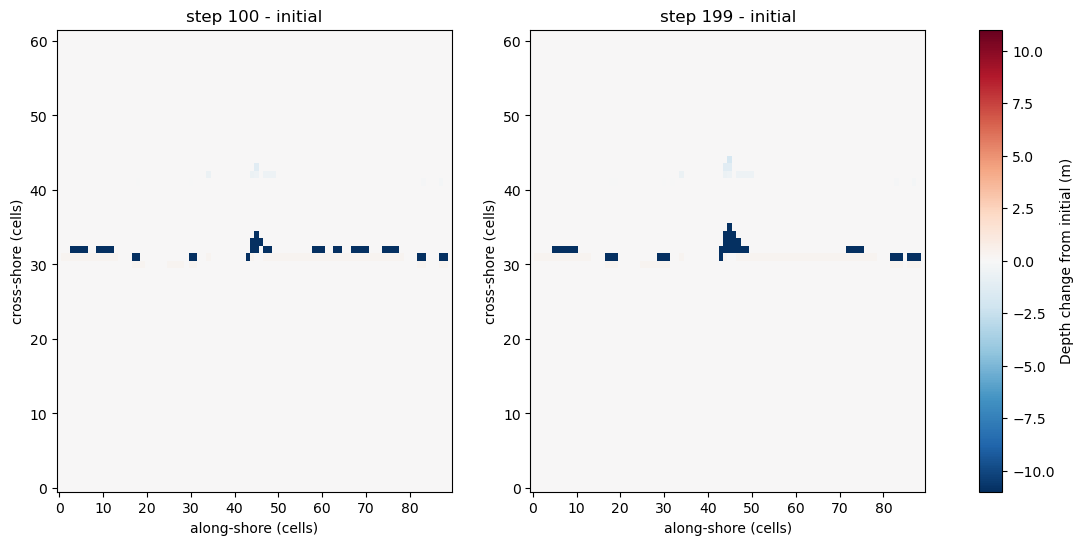

In [10]:
# 2) Change from initial (erosion / accretion)
z0 = frames[0][1]
panels = [(f"step {s} - initial", z - z0) for s, z in pick_frames(KEY_STEPS[1:])]
dmax = max(np.abs(p[1]).max() for p in panels)
norm = mcolors.TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
fig, axes = plt.subplots(1, len(panels), figsize=(7*len(panels), 6), squeeze=False)
for ax, (lbl, dz) in zip(axes[0], panels):
    im = ax.imshow(dz, origin="lower", cmap="RdBu_r", norm=norm, aspect="auto")
    ax.set_title(lbl)
    ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
fig.colorbar(im, ax=axes[0], label="Depth change from initial (m)")
plt.show()

## 7. Lightweight animation (inline, no GIF by default)

In [11]:
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"

z0 = frames[0][1]
dmax = max(np.abs(z - z0).max() for _, z in frames)
norm = mcolors.TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(frames[0][1] - z0, origin="lower", cmap="RdBu_r", norm=norm, aspect="auto")
ax.contour(frames[0][1], levels=[0], colors="black", linewidths=1.2)
ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
fig.colorbar(im, ax=ax, label="Depth change from initial (m)")
title = ax.set_title("")

def _update(i):
    step, z = frames[i]
    im.set_data(z - z0)
    for coll in ax.collections[1:]:
        coll.remove()
    ax.contour(z, levels=[0], colors="black", linewidths=1.2)
    title.set_text(f"step {step}")
    return [im]

anim = FuncAnimation(fig, _update, frames=len(frames), interval=200, blit=False)
plt.close(fig)
anim
# To save: anim.save("evolution.gif", writer="pillow", fps=5)

## Notes

- **Switching beach:** change `SITE` (e.g. `usa_NC_0031`, `usa_SC_0021`, ...) and
  re-run. `usa_XX_00nn` folders live under `DATA_DIR`.
- **Land direction is automatic** when generating from the dataset (it is the
  opposite of the mean seaward transect direction). If the input-shoreline plot's
  green arrow points to sea, set `LAND_DIR` to its opposite in the Parameters cell.
- **Run length:** the v0 build crashes some geometries past ~100 steps
  (`xtest is uninitialized!`); lower `N_STEPS` if so.
- **Diagonal coasts:** CEM represents the shore as one cross-shore position per
  along-shore column, so a strongly diagonal coast can evolve oddly. If needed we
  can rotate the `.xy` so the coast runs roughly horizontal before gridding.
- Portable env for DCC:
  `mamba create -n cemrun -c conda-forge python=3.11 pymt pymt_cem numpy scipy matplotlib ipykernel`
